In [78]:
import json

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

import arviz as az

from utils import plot_act_density, plot_location

## Loading scenario, original parameters and posterior data

{1: {'x': 315, 'y': 12, 'act': 1879, 'dist': 12},
 2: {'x': 265, 'y': 10, 'act': 35, 'dist': 10}}

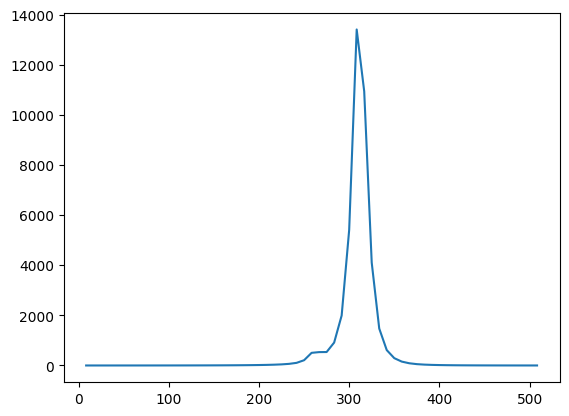

In [115]:
SIM_ID = 8

trace = az.from_netcdf(f"trace_output/{SIM_ID}_trace")
df = pd.read_pickle(f"trace_output/{SIM_ID}_pkl")
with open(f"trace_output/{SIM_ID}_real_params", 'r') as file:
    real_params = json.load(file)
real_params = {int(k):v for k,v in real_params.items()}

plt.plot(df["Dist"], df["ROI_P"])

real_params

## Posterior analysis

In [116]:
az.summary(trace, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
y_src[0],-2.41,370.85,-510.35,494.76,10.17,2.52,1346.23,1925.88,1.0
y_src[1],7.87,0.06,7.76,7.98,0.00,0.00,1815.46,2448.90,1.0
x_src[0],-199.15,291.58,-516.90,404.57,6.59,4.73,2088.28,2072.79,1.0
x_src[1],319.46,0.05,319.37,319.55,0.00,0.00,2735.65,2507.57,1.0
act_src[0],798.25,1871.75,0.56,2791.32,36.46,134.55,2241.59,2042.14,1.0
act_src[1],728.15,7.22,714.54,741.00,0.17,0.11,1828.34,2411.63,1.0


array([[<Axes: title={'center': 'y_src\n0'}>,
        <Axes: title={'center': 'y_src\n0'}>],
       [<Axes: title={'center': 'y_src\n1'}>,
        <Axes: title={'center': 'y_src\n1'}>],
       [<Axes: title={'center': 'x_src\n0'}>,
        <Axes: title={'center': 'x_src\n0'}>],
       [<Axes: title={'center': 'x_src\n1'}>,
        <Axes: title={'center': 'x_src\n1'}>],
       [<Axes: title={'center': 'act_src\n0'}>,
        <Axes: title={'center': 'act_src\n0'}>],
       [<Axes: title={'center': 'act_src\n1'}>,
        <Axes: title={'center': 'act_src\n1'}>]], dtype=object)

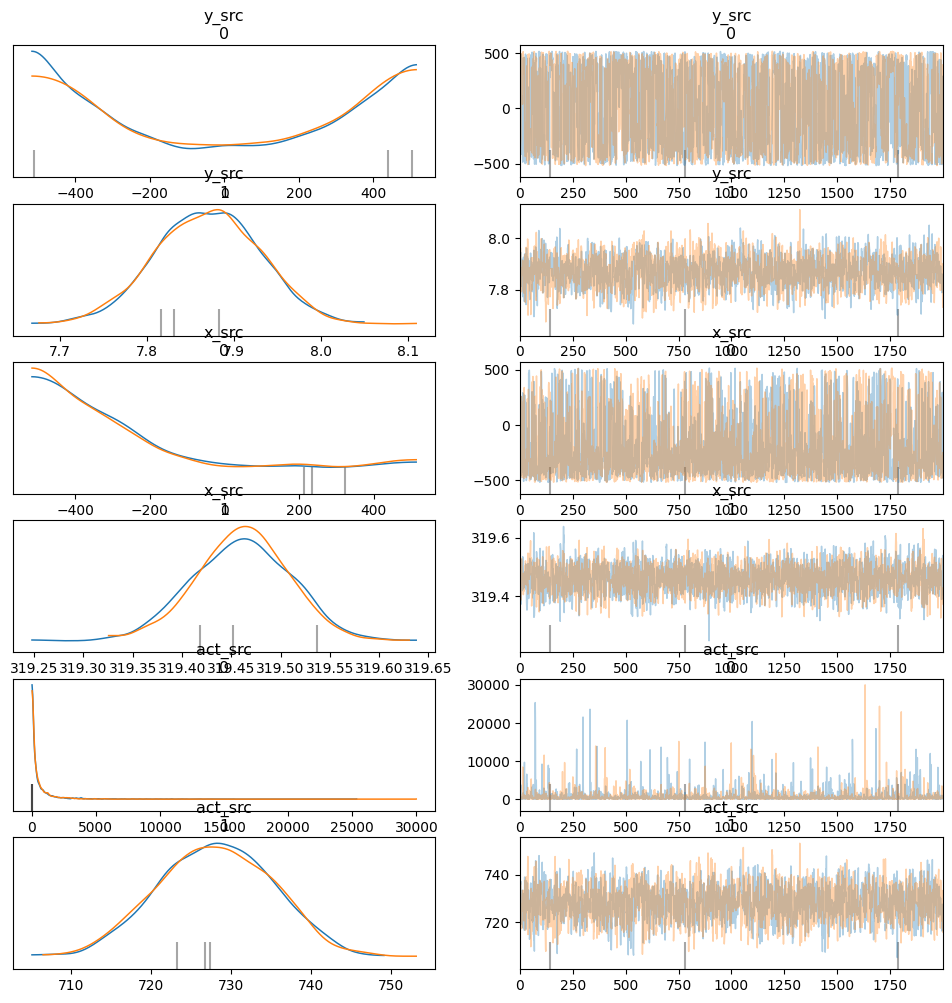

In [117]:
az.plot_trace(trace, compact=False)

In [118]:
posterior = trace.posterior
n_sources = posterior.sizes["sources"]
act_samples = {}

for i in range(n_sources):
    act_samples[i+1] = (
        posterior["act_src"]
        .sel(sources=i)
        .values
        .reshape(-1)
    )

x_samples = posterior.x_src.stack(sample=("chain","draw")).transpose("sources","sample").values
y_samples = posterior.y_src.stack(sample=("chain","draw")).transpose("sources","sample").values
a_samples = posterior.act_src.stack(sample=("chain","draw")).transpose("sources","sample").values

samples = np.concatenate([x_samples, y_samples, a_samples], axis=0)
samples

array([[-512.79064759, -513.41776304, -465.72556564, ..., -386.17784179,
        -468.43372036, -248.51792512],
       [ 319.51811457,  319.50772443,  319.42616506, ...,  319.39687817,
         319.42750593,  319.40580096],
       [ -67.35869685,   88.64542875,  428.13935475, ...,   20.60317055,
        -352.69778092,  393.64379819],
       [   7.90545608,    7.91950671,    7.93820134, ...,    7.88180503,
           7.85843332,    7.73233424],
       [1366.33114628,  916.16819266, 2230.22187567, ...,  276.36919479,
         150.51708572,  178.44442266],
       [ 741.51552994,  738.73886316,  735.81321381, ...,  728.74450507,
         725.01734813,  715.86878864]], shape=(6, 4000))

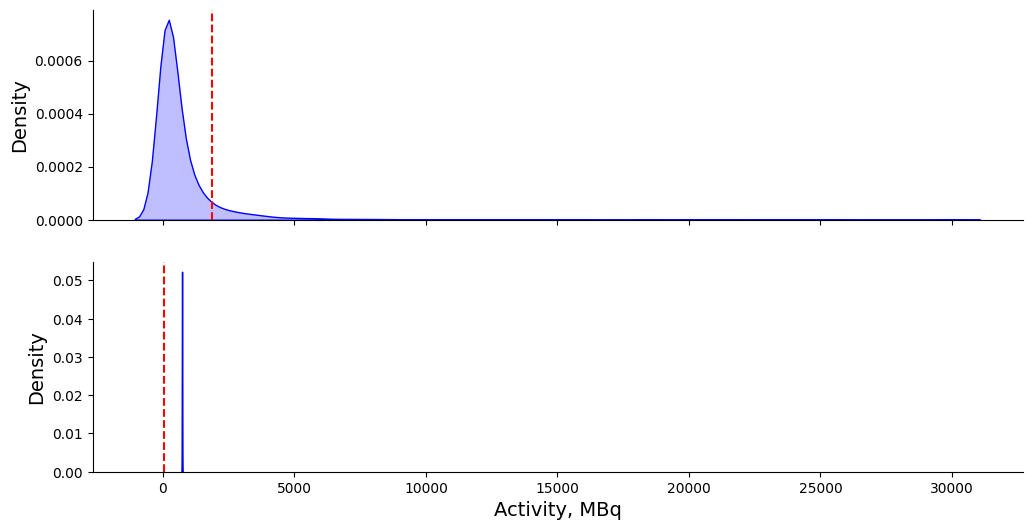

In [119]:
plot_act_density(act_samples, true_act=[k['act'] for k in real_params.values()])

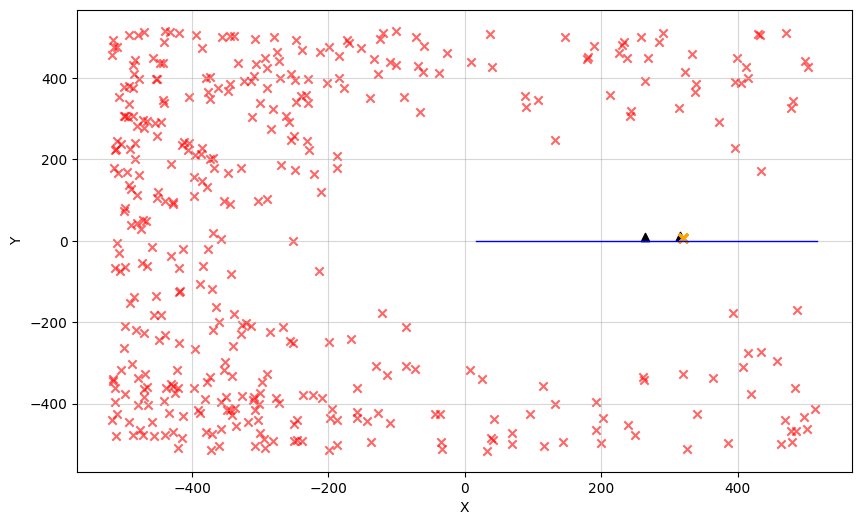

In [120]:
ref_coords_x = [real_params[j+1].get("x") for j in range(len(real_params))]
ref_coords_y = [real_params[j+1].get("y") for j in range(len(real_params))]

plot_location(
    df,
    ref_coords_x,
    ref_coords_y,
    x_samples,
    y_samples
)